Visualize out of shelter runs

In [2]:
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = {"JAL4_3rdSept": JAL4_3rdSept,
        "JAL4_19thSept": JAL4_19thSept,
        "JAL4_28aug": JAL4_28aug,
        "JAL4_11thSept": JAL4_11thSept,
        "JAL5_8thSept": JAL005_8thSept,
        "JAL5_21stSept": JAL005_21stSept,
        "JAL6_28mar": JAL6_28mar, 
        "JAL6_flip4_21mar": JAL6_flip4_21mar, 
        "JAL6_flip3_18mar": JAL6_flip3_18mar, 
        "JAL6_flip5_25mar": JAL6_flip5_25mar, 
        "JAL7_sesh8_9apr": JAL7_sesh8_9apr, # almost no homings
        "JAL7_flip5_22mar": JAL7_flip5_22mar, 
        "JAL7_flip2_12mar": JAL7_flip2_12mar, 
        "JAL7_sesh9_16apr": JAL7_sesh9_16apr, 
        "JAL7_23apr": JAL7_23apr,
        "JAL8_flip1_25apr": JAL8_flip1_25apr, 
        "JAL8_flip2_29apr": JAL8_flip2_29apr, 
        "JAL8_flip3_7may": JAL8_flip3_7may, 
        "JAL8_14may": JAL8_14may, 
        "JAL8_flip4_10may": JAL8_flip4_10may}

In [3]:
%load_ext autoreload
%autoreload 2

from behave_analysis.process.process import Process
from behave_analysis.analyze.CCA.find_shelter_exit_and_runs import find_shelter_exit_runs, find_bout_runs
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe
from behave_analysis.utils.arena_plotting import Arena

import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import os

%matplotlib inline
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
COLUMNS_TO_KEEP = ["hdir", "mouse_x_position", "mouse_y_position", "speed", "hsa", "h_preflipbar_a", "h_postflipbar_a", "distance_to_shelter", "distance_to_barrier1", "distance_to_barrier2"]

In [ ]:
"""Load behavioral data"""
session_name = list(experiments_objects.keys())[8]
exp = experiments_objects[session_name]
session = Process(exp).load_session()
session_start = max(session.shelter_time[0]*60*40, 30*40) # start at shelter_time or 30s, whichever is later
video_df = pl.read_csv(os.path.join(session.base_path, session.processed_path) + "\\" + "full_video_dataframe.csv")

2026-04-21 11:28:11.238 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


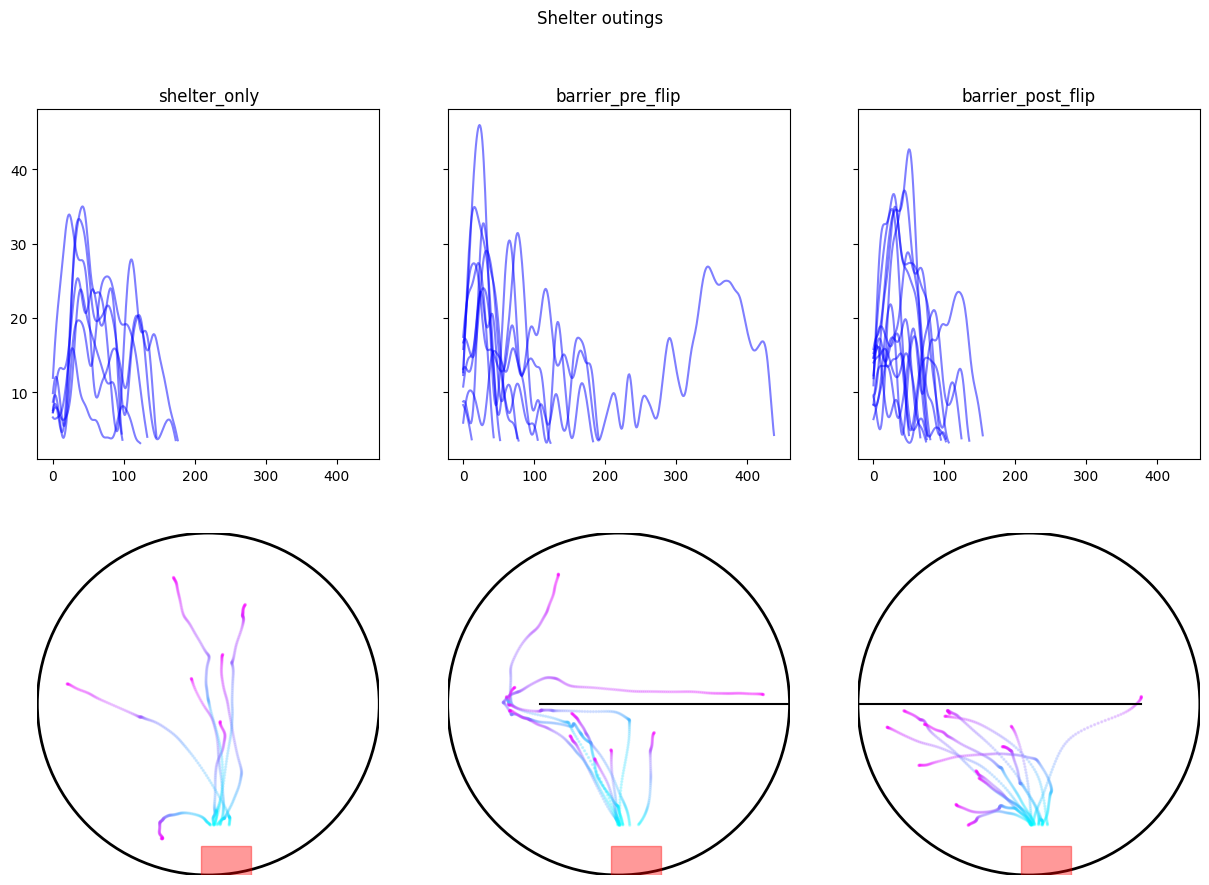

In [15]:
"""Visualize the runs and their speed profiles"""

cap = 20
shelter_outings = find_shelter_exit_runs(
    video_df,
    min_speed_cm_s=3.0,
    min_distance_cm=20.0,
)
bout_runs = find_bout_runs(video_df, min_distance_cm=40, remove_shelter_outings=True)
# bool_vec, bool_name = bout_runs, "Bout runs"
bool_vec, bool_name = shelter_outings, "Shelter outings"
# bool_name = "Homing + escapes"

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex="row", sharey="row")
for c, cond in enumerate(cond_list):
    if bool_name == "Homing + escapes":
        indices = (
            filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=False, select_homings=True, select_escape=True)["frames"].to_numpy() - 1
        )
    else:
        frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
        indices = np.array([idx for idx in np.where(bool_vec)[0] if idx in frames_by_condition_explore])
    # plot speed traces
    Arena(ax=axs[1,c], condition=cond, barrier_coordinates=session.barrier_location[:-1], full_image=False)
    start = np.concatenate([np.zeros(1), np.where(np.diff(indices) > 1)[0] + 1, np.array([len(indices)])]).astype(int)
    for s in range(len(start[:-1])):
        if s > cap:
            break
        seg = np.arange(indices[start[s]], indices[start[s+1]-1])
        axs[0,c].plot(video_df["speed"].to_numpy()[seg], color = 'blue', alpha = 0.5)
        axs[1,c].scatter(video_df["mouse_x_position"].to_numpy()[seg], video_df["mouse_y_position"].to_numpy()[seg], 
                         c = np.linspace(0, 1, len(seg)) if len(seg) > 1 else np.array([0.0]), cmap = "cool",
                         s=2, alpha = 0.2, label = "Out of shelter runs" if s == 0 else None)
    axs[0,c].set_title(f"{cond_list[c]}")
    
    fig.suptitle(bool_name)

Visualize neural activity in bout runs

In [5]:
from settings.settings_overrides import settings_overrides
from behave_analysis.analyze.results_database_utils import check_database_for_same_run, settings_to_check
from settings.settings_analyze_efizz import Settings_ae
import matplotlib.gridspec as gridspec
import dill as pickle
from behave_analysis.analyze.EscapePattern.escape_pattern_utils import homing_escape_filtering_vector, compute_tuning_stat, check_not_list, compute_dist_shelt

In [6]:
"""Load neural data"""
fcm = np.load(os.path.join(session.base_path, session.processed_path) + "\\" + "frame_by_good_cluster_matrix.npy")
mean_fcm = np.nanmean(fcm, axis=0)
std_fcm = np.nanstd(fcm, axis=0)
fcm_z = (fcm - mean_fcm) / std_fcm
homing_path = os.path.join(session.base_path, session.processed_path, "homings", "homings_obj.pkl")
with open(homing_path, "rb") as f:
    homings_object = pickle.load(f)

escape_path = os.path.join(session.base_path, session.processed_path, "escapes", "escapes_obj.pkl")
with open(escape_path, "rb") as f:
    escape_object = pickle.load(f)

In [10]:
"""Load tuning data"""

tuning_settings = {'ep_bins': 25,
                    'ep_no_stationary': False,
                    'ep_interpolation_mult': 2,
                    'ep_gaussian_fitting': False,
                    'ep_compute_loo_reliability': False,
                    'ep_tuned_compare_method': 'euclidean',
                    'ep_tuned_stats': 'bootstrap',
                    'ep_tuned_stats_samples': 100,
                    'linshift_min_step': 120,
                    'linshift_step': 80,
                    'linshift_step_n': 100,
                    'stim_type': 'audio',
                    'cluster_type': 'good',
                    'condition_types': 'experimental_conditions',
                    'compartment_split': ['all'],
                    'redo_compute': False}
var = "escape in homing&escape"
var = "escape in correct_full_homing&escape"
# var = "bird_dist_shelter in homing&escape"
Settings_ae = settings_overrides(Settings_ae, tuning_settings)
settings_dict = {"variable": var, **settings_to_check(Settings_ae, ["ep_"])}
savepath = os.path.join(session.base_path, session.processed_path, "models", "escape_tuning")
    
database, do_analysis, hexaname = check_database_for_same_run(settings_dict, 
                                                                savepath + os.sep + "EscapePattern_results.csv", 
                                                                Settings_ae)
if not do_analysis:
    data_file = os.path.join(savepath, f"EPtuning_{hexaname}_results.npz")
    ep_data = np.load(data_file, allow_pickle=True)
    real_stat, shift_stat = compute_tuning_stat(stat='zscore_peak', 
                                                shifted_matrix=ep_data['fr_shift'], 
                                                shift0=int(np.shape(ep_data['fr_shift'])[0] / 2), 
                                                neural_matrix=ep_data['neural_matrix'], 
                                                condition=ep_data['condition'])
    sig_cells = real_stat > np.nanpercentile(shift_stat, 95, axis=0)

# make condition vector
condition  = np.zeros(len(video_df))
condition[video_df["barrier_present"]] += 1
condition[video_df["barrier_flipped"]] += 1

2026-04-21 11:31:12.750 | INFO     | behave_analysis.analyze.results_database_utils:check_database_for_same_run:23 - Found 1 matched results in database: ['fa4635b40b8c4393'] in the folder Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_barrier_flip2_2024_03_18T11_53_29\processed_data\models\escape_tuning\EscapePattern_results.csv


In [8]:
def homing_escape_onsets(video_df, escape_object, homings_object, session, escape_pattern_time, spatial_efficiency_threshold=[0.9, 1.05]):
    """This function creates two vectors of onset and offset times for homing and escape periods
    TODO: currently does not filter based on first/second leg, or minimum homing length
    RETURNS:
        ons: vector of onset times in frames for homing and escape periods
        offs: vector of offset times in frames for homing and escape periods
        esc_ons: vector of onset times in frames for escape periods
    """

    ons = []
    offs = []
    esc_ons = []
    trajectory_length = []
    condition = []

    # check if we want to include escapes
    if "escape" in escape_pattern_time:
        # pull out escape onsets and calculate offset estimate based on stimulus duration (assuming 40 fps) - mouse will likely lon gbe in shelter by then
        esc_ons = np.array(check_not_list(escape_object.onset_frames))
        not_nan = np.where(~np.isnan(esc_ons))[0]  # if the mouse didn't perform an escape after the stim!
        ons = np.append(ons, esc_ons[not_nan])
        offs = np.append(offs, np.array(check_not_list(escape_object.offset_frames))[not_nan])
        trajectory_length = np.append(trajectory_length, escape_object.trajectory_length[not_nan])
        condition = np.append(condition, [c for idx, c in enumerate(escape_object.condition) if idx in not_nan])

    if "homing" in escape_pattern_time:
        # pull out homing onsets and offsets
        ons = np.append(ons, check_not_list(homings_object.onset_frames))
        offs = np.append(offs, check_not_list(homings_object.offset_frames))
        trajectory_length = np.append(trajectory_length, homings_object.trajectory_length)
        condition = np.append(condition, homings_object.condition)

    # combine homing and escape onsets and offsets
    idx = np.argsort(ons)
    ons = ons[idx]
    offs = offs[idx]
    trajectory_length = trajectory_length[idx]
    condition = condition[idx]

    # compute spatial efficiency for each run
    optimal_distances = np.zeros(len(ons))
    for idx in range(len(ons)):
        dist_to_shelter = compute_dist_shelt(
            x_pos=np.array([video_df["mouse_x_position"].to_numpy()[int(ons[idx])]]),
            y_pos=np.array([video_df["mouse_y_position"].to_numpy()[int(ons[idx])]]),
            cond=np.array([x for x, c in enumerate(cond_list) if c == condition[idx]]),
            shelter_location=[np.mean([session.shelter_location[0][0], session.shelter_location[1][0]]), session.shelter_location[0][1]],
            barrier_location1=session.barrier_location[0],
            barrier_location2=session.barrier_location[1],
        )
        optimal_distances[idx] = dist_to_shelter[0]

    spatial_efficiency = optimal_distances / trajectory_length

    keepers = np.ones_like(ons, dtype=bool)

    if "correct" in escape_pattern_time:  # homings with spatial efficiency of 0.95-1.05 are considered correct
        keepers = keepers & ((spatial_efficiency > spatial_efficiency_threshold[0]) & (spatial_efficiency < spatial_efficiency_threshold[1]))
    if "error" in escape_pattern_time:
        keepers = keepers & ((spatial_efficiency < spatial_efficiency_threshold[0]) | (spatial_efficiency > spatial_efficiency_threshold[1]))
    if "full" in escape_pattern_time:  # homings that go from the threat zone-ish to the shelter-ish
        starts = np.array([video_df["mouse_y_position"].to_numpy()[int(on)] for on in ons])
        ends = np.array([video_df["mouse_y_position"].to_numpy()[int(off)] for off in offs])
        keepers = keepers & (starts < 300) & (ends > 800)
    if "not" in escape_pattern_time:
        keepers = ~keepers

    return {
        "ons": ons[keepers],
        "offs": offs[keepers],
        "esc_ons": np.array([e for e in esc_ons if e in ons[keepers]]),
        "condition": condition[keepers],
        "trajectory_length": trajectory_length[keepers],
        "spatial_efficiency": spatial_efficiency[keepers],
    }

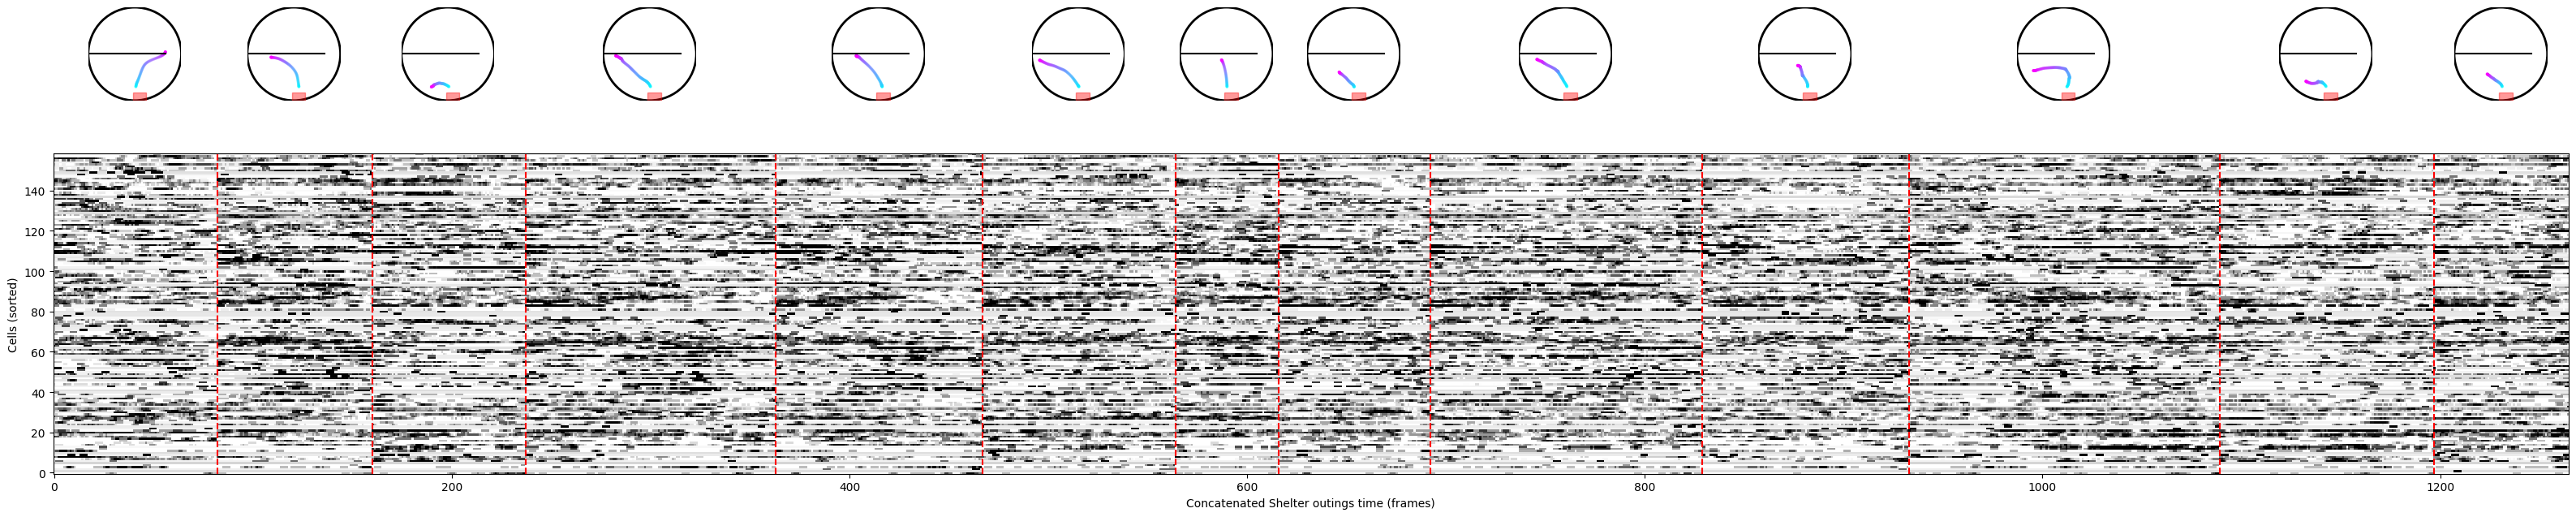

In [18]:
bool_vec, bool_name = bout_runs, "Bout runs"
bool_vec, bool_name = shelter_outings, "Shelter outings"
# bool_name = "homing&escape" 
# bool_name = "correct_full_homing&escape"
cond = 2
cap = 20

if "homing" in bool_name:
    onset_dict = homing_escape_onsets(video_df, escape_object, homings_object, session, escape_pattern_time=bool_name)
    h_e_vec, _ = homing_escape_filtering_vector(
                                                nframes=len(video_df),
                                                onset_dict=onset_dict,
                                                xpos=video_df["mouse_x_position"].to_numpy(),
                                                ypos=video_df["mouse_y_position"].to_numpy(),
                                                shelter_location=session.shelter_location,
                                            )
    indices = video_df["frames"].to_numpy()[h_e_vec] - 1
else:
    # frames_by_condition_explore = filter_video_dataframe(video_df, condition=cond, outofshelter=True, exclude_escape=True, exclude_homings=True)["frames"].to_numpy() - 1
    # indices = np.array([idx for idx in np.where(bool_vec)[0] if idx in frames_by_condition_explore])
    indices = np.where(bool_vec)[0]

tuning_hm = ep_data['fr_full'][cond, sig_cells[cond,:], :]
tuning_hm = np.divide(tuning_hm - mean_fcm[sig_cells[cond,:], np.newaxis],
                        std_fcm[sig_cells[cond,:], np.newaxis],
                        out=np.zeros_like(tuning_hm, dtype=np.float64),
                        where=std_fcm[sig_cells[cond,:], np.newaxis] != 0)
sort_idx = np.argsort(np.argmax(tuning_hm, axis=1))
indices_this_cond = indices[condition[indices] == cond]
neural = fcm_z[indices_this_cond, :][:, sig_cells[cond,:]]
# bout boundaries in indices_this_cond space
starts = np.concatenate(([0], np.where(np.diff(indices_this_cond) > 1)[0] + 1))
ends = np.concatenate((starts[1:], [len(indices_this_cond)]))

# optionally cap number of bouts
if cap is not None:
    starts = starts[:cap]
    ends = ends[:cap]

durations = ends - starts

# build concatenated heatmap in same order as displayed bouts
# neural is (time x cells), so transpose to (cells x time)
heatmap_parts = [neural[s:e, :][:, sort_idx].T for s, e in zip(starts, ends)]
heatmap = np.concatenate(heatmap_parts, axis=1)

# cumulative boundaries in heatmap x coordinates
boundary_x = np.cumsum(durations)[:-1]

# figure with top behavior row + bottom neural heatmap
fig = plt.figure(figsize=(max(12, cap*2), 8))
gs = gridspec.GridSpec(
    nrows=2, ncols=1,
    height_ratios=[1, 2.0],
    hspace=0.08
)

ax_hm = fig.add_subplot(gs[1])
ax_hm.imshow(
    heatmap,
    aspect="auto",
    origin="lower",
    cmap="gray_r",
    vmin=-0.5, vmax=2,
    interpolation="none"
)

for x in boundary_x:
    ax_hm.axvline(x=x, color="red", linestyle="--", linewidth=1.5)

ax_hm.set_xlabel(f"Concatenated {bool_name} time (frames)")
ax_hm.set_ylabel("Cells (sorted)")

# fixed-size top panels, centered on each bout interval in heatmap coordinates
hm_box = ax_hm.get_position()          # figure coords
top_box = gs[0].get_position(fig)      # y-range reserved for top row

interval_starts = np.concatenate(([0], np.cumsum(durations[:-1])))
interval_centers = interval_starts + durations / 2.0
total_w = float(np.sum(durations))

# all top plots same width/height
fig_w, fig_h = fig.get_size_inches()
min_dur = np.min(durations)
total_w = float(np.sum(durations))
# size implied by smallest interval
side_from_data_in = (hm_box.width * (min_dur / total_w) * 0.9) * fig_w
# hard caps so few-bout cases do not explode
max_side_from_top_in = (top_box.height * 0.90) * fig_h
max_side_abs_in = 1.6   # tune this if you want bigger/smaller arenas
side_in = min(side_from_data_in, max_side_from_top_in, max_side_abs_in)
# square axes in figure-fraction units
top_w = side_in / fig_w
top_h = side_in / fig_h
top_y = top_box.y0 + (top_box.height - top_h) / 2.0

for i, (s, e, c_mid) in enumerate(zip(starts, ends, interval_centers)):
    # map interval center (data x) -> figure x
    cx = hm_box.x0 + (c_mid / total_w) * hm_box.width
    left = np.clip(cx - top_w / 2.0, hm_box.x0, hm_box.x0 + hm_box.width - top_w)

    ax_xy = fig.add_axes([left, top_y, top_w, top_h])

    frames = indices_this_cond[s:e]
    Arena(
        ax=ax_xy,
        condition=cond_list[cond],
        barrier_coordinates=session.barrier_location[:-1],
        full_image=False
    )

    prog = np.linspace(0, 1, len(frames)) if len(frames) > 1 else np.array([0.0])
    ax_xy.scatter(
        video_df["mouse_x_position"].to_numpy()[frames],
        video_df["mouse_y_position"].to_numpy()[frames],
        c=prog, cmap="cool", vmin=0, vmax=1,
        s=3, alpha=0.35
    )
    ax_xy.set_xticks([])
    ax_xy.set_yticks([])
